# Explore the bee microbiome use case

In [3]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data_dp = Path("../data/use-cases/bee-microbiome/")
data_dp.exists()

result_dp = Path("../results/use-cases/bee-microbiome/")
result_dp.exists()

True

In [35]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


# MAGs assigned taxonomy

In [64]:
levels = pd.DataFrame(0, index=["Genus", "Species"], columns=["count", "Species-level MAG count"])

for l in levels.index:
    if l in df_expert.columns:
        levels.loc[l, "count"] = df_expert[l].notna().sum()
        levels.loc[l, "Species-level MAG count"] = df_expert.loc[df_expert[l].notna(), "Species-level MAG count"].sum()
    else:
        print(f"Column '{l}' not found in the DataFrame.")
levels

,count,Species-level MAG count
Genus,38,161
Species,32,148


In [67]:
100*levels.loc["Species","Species-level MAG count"]/levels.loc["Genus","Species-level MAG count"]

np.float64(91.92546583850931)

In [71]:
def get_level_counts(df, level):
    """
    Get counts of non-empty values for a taxonomic level in the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    level (str): The level to group by in the DataFrame.
    
    Returns:
    pd.DataFrame: A DataFrame with counts and Species-level MAG counts for each level.
    """
    level_group = df.groupby(level)

    # Create count summary
    level_counts = level_group.size().sort_values(ascending=False).to_frame("count")
    level_counts["percentage"] = 100*level_counts["count"] / level_counts["count"].sum()

    # Create MAG count summary
    level_mag_counts = level_group["Species-level MAG count"].sum().sort_values(ascending=False).to_frame("Total MAG count")

    # Merge the two dataframes
    level_summary = pd.concat([level_counts, level_mag_counts], axis=1)
    level_summary.sort_values(by="Total MAG count", ascending=False, inplace=True)

    # Add totals row
    level_summary.loc["TOTAL"] = level_summary.sum(numeric_only=True)
    level_summary.loc["TOTAL", "percentage"] = 100.0  # Percentage for TOTAL should be 100

    return level_summary

display(get_level_counts(df_expert, "Phylum"))
display(get_level_counts(df_expert, "Class"))
display(get_level_counts(df_expert, "Order"))
display(get_level_counts(df_expert, "Family"))
display(get_level_counts(df_expert, "Genus"))
display(get_level_counts(df_expert, "Species"))

,count,percentage,Total MAG count
Phylum,,,
Pseudomonadota,23.0,60.526316,77.0
Bacillota,9.0,23.684211,58.0
Bacillota_A,4.0,10.526316,12.0
Actinomycetota,1.0,2.631579,8.0
Bacteroidota,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Class,,,
Gammaproteobacteria,19.0,50.000000,70.0
Bacilli,9.0,23.684211,58.0
Clostridia,4.0,10.526316,12.0
Actinomycetes,1.0,2.631579,8.0
Alphaproteobacteria,4.0,10.526316,7.0
Bacteroidia,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Order,,,
Lactobacillales,8.0,21.052632,57.0
Enterobacterales,13.0,34.210526,52.0
Lachnospirales,3.0,7.894737,11.0
Pseudomonadales,4.0,10.526316,9.0
Burkholderiales,2.0,5.263158,9.0
Actinomycetales,1.0,2.631579,8.0
Rhizobiales,4.0,10.526316,7.0
Flavobacteriales,1.0,2.631579,6.0
Bacillales_D,1.0,2.631579,1.0


,count,percentage,Total MAG count
Family,,,
Enterobacteriaceae,13.0,34.210526,52.0
Lactobacillaceae,7.0,18.421053,50.0
Lachnospiraceae,3.0,7.894737,11.0
Pseudomonadaceae,4.0,10.526316,9.0
Neisseriaceae,2.0,5.263158,9.0
Bifidobacteriaceae,1.0,2.631579,8.0
Rhizobiaceae,4.0,10.526316,7.0
Enterococcaceae,1.0,2.631579,7.0
Weeksellaceae,1.0,2.631579,6.0


,count,percentage,Total MAG count
Genus,,,
Apilactobacillus,2.0,5.263158,19.0
Frischella,1.0,2.631579,17.0
Fructobacillus,1.0,2.631579,17.0
Proteus,1.0,2.631579,12.0
Lactobacillus,3.0,7.894737,10.0
Novisyntrophococcus,2.0,5.263158,10.0
Klebsiella,1.0,2.631579,9.0
Entomomonas,4.0,10.526316,9.0
Snodgrassella,2.0,5.263158,9.0


,count,percentage,Total MAG count
Species,,,
Frischella perrara,1.0,3.125,17.0
Fructobacillus fructosus,1.0,3.125,17.0
Apilactobacillus kunkeei_C,1.0,3.125,15.0
Proteus mirabilis,1.0,3.125,12.0
Novisyntrophococcus liquoris,1.0,3.125,9.0
Klebsiella oxytoca,1.0,3.125,9.0
Snodgrassella alvi,1.0,3.125,8.0
Bifidobacterium indicum,1.0,3.125,8.0
Enterococcus faecalis,1.0,3.125,7.0


# Comparison of MAGs taxonomy with original study

## Statistics for MAGs origin

In [34]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


In [ ]:
print(f"Percentage of species identified by MAGs listed in the paper: {100*origin_df.loc['Built MAG, Species listed in the paper', 'count']/levels.loc['Species', 'count'] if levels.loc['Species', 'count'] > 0 else None}")

Percentage of found MAGs listed in the paper: 59.375


## Species identified by MAGs

### Concordant = corresponding to species listed in the paper 

In [ ]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

In [42]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


### Non concordant = NOT corresponding to species listed in the paper

In [46]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [45]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


### Comparison of completess and contamination between concordant and non-concordant species

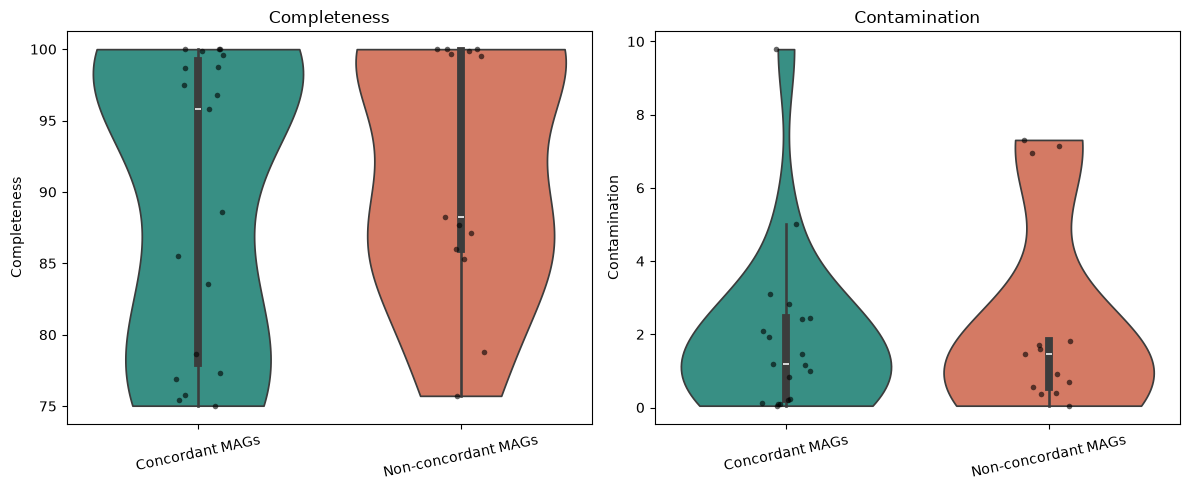

In [ ]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()